# Recursive forecasting: how far can the model trust itself?

Every other notebook in this project asks the model to look at 2 hours of history and predict one value, 60 minutes ahead, in a single shot. That's the paper's own setup, and it's a reasonable thing to ask a model to do -- but it also means the model never has to live with its own mistakes. This notebook asks a different question: what happens if the model has to keep predicting forward, using its own earlier predictions as if they were real data, instead of always getting a fresh window of ground truth?

## Why this needs a different model, not just a different question

The existing models take 6 inputs per timestep (glucose, background insulin, meal insulin, carbs, a glucose moving average, and a hypo/normal/hyper label) and output exactly one thing: glucose, 60 minutes later. To run recursively -- feed a prediction back in as input for the next prediction -- the model has to predict *all* the things it needs as input, not just glucose, or it has no way to keep going without secretly relying on real future data it wouldn't actually have.

Two of those 6 inputs (the moving average, the hypo/normal/hyper label) are just simple calculations on top of the glucose history, so they don't need their own model. The other four -- glucose, background insulin, meal insulin, carbs -- all need to be predicted directly. This notebook trains one small model to do exactly that: given the last 2 hours, predict all four, 5 minutes ahead. Then it's run recursively: predict one step, treat that prediction as real, predict the next step from it, and so on.

Worth flagging up front: background insulin changes slowly and predictably, but meal insulin and carbs are the opposite -- a person eats or doses at a handful of specific moments and does nothing the rest of the time. A model trained to minimize average error on that kind of sparse, spiky data will likely learn to predict something close to zero most of the time, since that's usually the safest guess. Whether that actually happens, and what it does to the recursive glucose forecast, is checked directly below rather than assumed.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d import reference as ref
from azt1d.glimmer import features as feat
from azt1d.glimmer import sequences as seq
from azt1d.glimmer import recursive as rec

plotting.apply_style()
pd.set_option("display.max_columns", None)

## 1. Load data, pick one patient

In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
SUBJECT_ID = 1  # the same illustrative patient used throughout this project
df_subject = df[df["subject_id"] == SUBJECT_ID].reset_index(drop=True)
print(f"Subject {SUBJECT_ID}: {len(df_subject):,} readings.")

Subject 1: 10,881 readings.


**Update after a first pass:** an earlier version of this notebook (no time-of-day feature) found the recursive glucose curve flatlining almost immediately, because the model had no way to know a meal might be coming and just predicted "probably nothing" for meal insulin and carbs the whole way through. Two extra input features are added below to give it that signal: sin/cos of time-of-day (meals cluster around particular times, already visible earlier in this project's own data exploration). Unlike glucose, insulin, and carbs, time doesn't need to be predicted during the rollout at all -- the clock is exactly known in advance -- so it's filled in directly rather than generated.

## 2. Train the multi-output, next-step model

In [3]:
data = rec.prepare_multi_output_data(df_subject)
print(f"train/val/test windows: {len(data.X_train)}/{len(data.X_val)}/{len(data.X_test)}")
print("Target columns:", rec.TARGET_COLUMNS)
print("Target means (train set):", dict(zip(rec.TARGET_COLUMNS, data.target_means.round(3))))
print("Target stds (train set):", dict(zip(rec.TARGET_COLUMNS, data.target_stds.round(3))))

train/val/test windows: 6949/1737/2171
Target columns: ['CGM', 'Basal', 'TotalBolusInsulinDelivered', 'CarbSize']
Target means (train set): {'CGM': np.float32(140.897), 'Basal': np.float32(1.98), 'TotalBolusInsulinDelivered': np.float32(0.493), 'CarbSize': np.float32(0.601)}
Target stds (train set): {'CGM': np.float32(37.116), 'Basal': np.float32(0.536), 'TotalBolusInsulinDelivered': np.float32(2.527), 'CarbSize': np.float32(4.756)}


In [4]:
result = rec.train_multi_output_model(data, architecture="cnn_lstm")
print(f"Trained. {result.n_params:,} parameters.")
print("Per-target validation RMSE (raw units):")
for col, val in result.per_target_val_rmse.items():
    print(f"  {col}: {val:.3f}")

Trained. 4,388 parameters.
Per-target validation RMSE (raw units):
  CGM: 10.468
  Basal: 0.299
  TotalBolusInsulinDelivered: 2.611
  CarbSize: 5.234


**Checking the sparse-target concern directly:** compare each target's validation RMSE above against simply guessing that target's own mean value every time. If the model's RMSE is barely better than the guess-the-mean baseline for bolus/carbs specifically, that's the predicted sparse-target collapse actually happening -- worth knowing before trusting the recursive curve's insulin/carb behavior.

In [5]:
baseline_rmse = {}
for j, col in enumerate(rec.TARGET_COLUMNS):
    mean_guess = data.Y_train[:, j].mean()
    baseline_rmse[col] = float(np.sqrt(np.mean((data.Y_val[:, j] - mean_guess) ** 2)))

comparison = pd.DataFrame({
    "model_rmse": result.per_target_val_rmse,
    "guess_the_mean_rmse": baseline_rmse,
})
comparison["model_beats_mean_by"] = comparison["guess_the_mean_rmse"] - comparison["model_rmse"]
comparison.round(3)

,model_rmse,guess_the_mean_rmse,model_beats_mean_by
CGM,10.468,38.012,27.544
Basal,0.299,0.935,0.636
TotalBolusInsulinDelivered,2.611,2.606,-0.005
CarbSize,5.234,5.241,0.007


## 3. Roll the model forward

Starting right at the beginning of this patient's held-out test data -- never seen during training -- and walking forward 100 steps (about 8.3 hours), feeding each step's own prediction back in as the next step's input.

In [6]:
model = rec.load_multi_output_model(result)
enriched = rec.add_all_features(df_subject)

N_STEPS = 100  # ~8.3 hours of 5-minute steps
n_train_val_windows = len(data.X_train) + len(data.X_val)
start_idx = n_train_val_windows + seq.LOOKBACK  # first row of the held-out test region

trajectory = rec.recursive_forecast(
    model, enriched, start_idx=start_idx, scaler=data.scaler,
    target_means=data.target_means, target_stds=data.target_stds, n_steps=N_STEPS,
)
trajectory.head()

,step,pred_CGM,pred_Basal,pred_TotalBolusInsulinDelivered,pred_CarbSize,actual_CGM,actual_Basal,actual_TotalBolusInsulinDelivered,actual_CarbSize,EventDateTime
0,0,159.644897,2.728667,0.924333,0.365937,159.0,2.808,0.0,0.0,2024-01-08 08:49:00
1,1,159.152969,2.663153,0.932992,0.462748,132.0,2.808,0.0,0.0,2024-01-08 08:54:00
2,2,158.850342,2.596604,0.891715,0.562355,143.0,3.000,0.0,0.0,2024-01-08 08:59:00
3,3,158.172226,2.538297,0.807059,0.586932,140.0,3.000,0.0,0.0,2024-01-08 09:04:00
4,4,157.038910,2.485196,0.731573,0.570577,140.0,3.000,0.0,0.0,2024-01-08 09:09:00


## 4. The curve, and the diff

Top: the actual glucose trace against what the model generated entirely from its own prior predictions. Bottom: the gap between them, plotted against how far into the recursive rollout each point is -- this is the direct answer to "how much does error grow the further out you go."

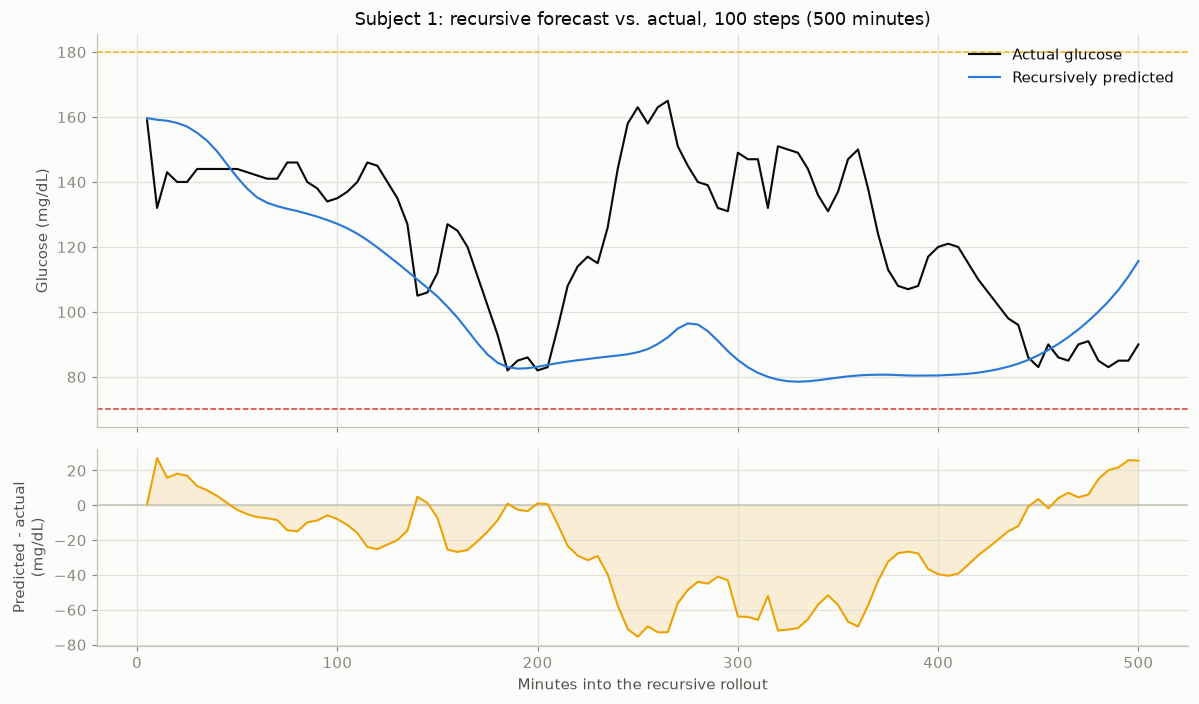

In [7]:
minutes_ahead = (trajectory["step"] + 1) * 5
error = trajectory["pred_CGM"] - trajectory["actual_CGM"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])

ax1.plot(minutes_ahead, trajectory["actual_CGM"], color=plotting.INK_PRIMARY, linewidth=1.4, label="Actual glucose")
ax1.plot(minutes_ahead, trajectory["pred_CGM"], color=plotting.CATEGORICAL[0], linewidth=1.4, label="Recursively predicted")
ax1.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
ax1.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_title(f"Subject {SUBJECT_ID}: recursive forecast vs. actual, {N_STEPS} steps ({N_STEPS*5} minutes)")
ax1.legend(frameon=False)

ax2.axhline(0, color=plotting.BASELINE, linewidth=1)
ax2.plot(minutes_ahead, error, color=plotting.CATEGORICAL[3], linewidth=1.3)
ax2.fill_between(minutes_ahead, error, 0, color=plotting.CATEGORICAL[3], alpha=0.15)
ax2.set_ylabel("Predicted - actual\n(mg/dL)")
ax2.set_xlabel("Minutes into the recursive rollout")

fig.tight_layout()
plt.show()

In [8]:
print(f"Mean absolute error, first 30 minutes:   {error[minutes_ahead <= 30].abs().mean():.1f} mg/dL")
print(f"Mean absolute error, last 30 minutes:     {error[minutes_ahead >= minutes_ahead.max() - 30].abs().mean():.1f} mg/dL")
print(f"Mean absolute error, whole rollout:       {error.abs().mean():.1f} mg/dL")
print(f"Max absolute error reached, and at what point:  {error.abs().max():.1f} mg/dL at minute {minutes_ahead[error.abs().idxmax()]}")

Mean absolute error, first 30 minutes:   15.0 mg/dL
Mean absolute error, last 30 minutes:     17.1 mg/dL
Mean absolute error, whole rollout:       28.0 mg/dL
Max absolute error reached, and at what point:  75.4 mg/dL at minute 250


## 5. What happened to the other three predictions

The recursive glucose curve above depends on what the model predicted for background insulin, meal insulin, and carbs at every step too, since those feed back in as input just like glucose does. Worth seeing directly, given the sparse-target concern raised at the start.

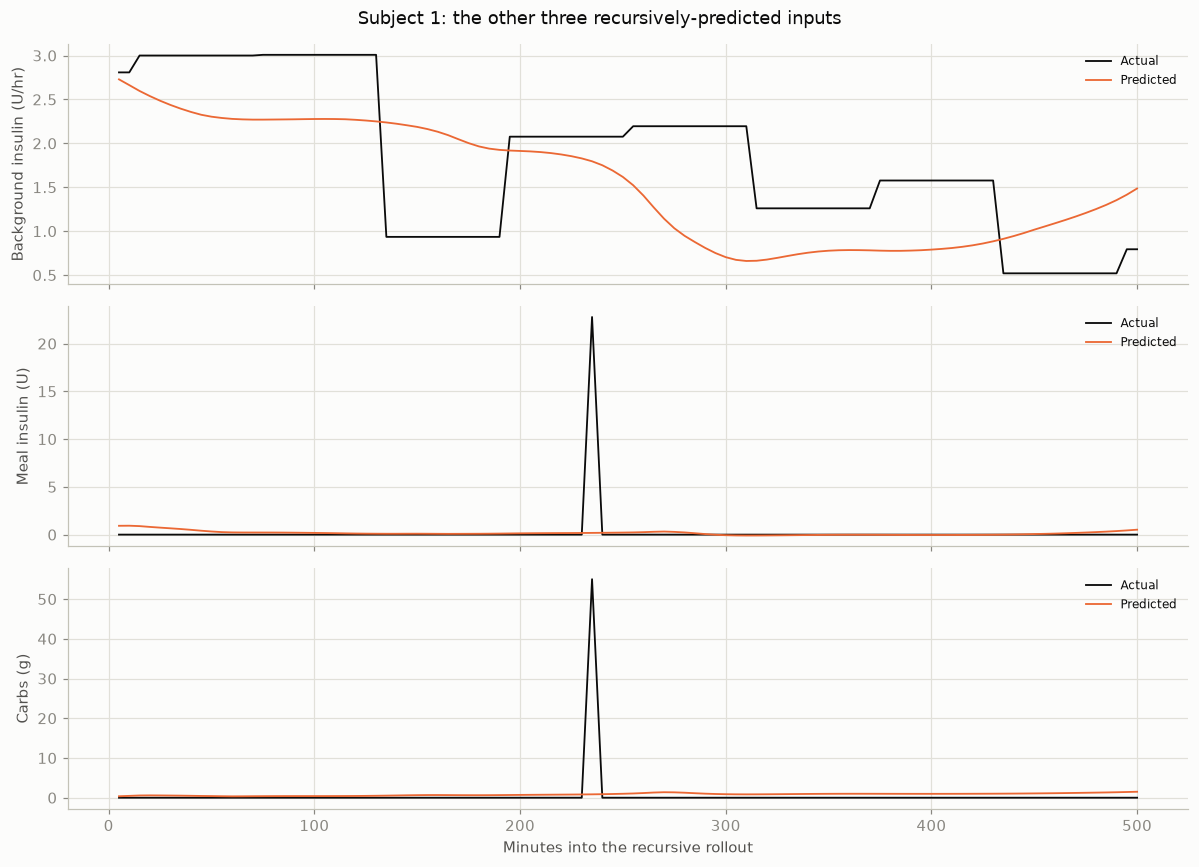

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
panels = [
    ("Basal", "Background insulin (U/hr)"),
    ("TotalBolusInsulinDelivered", "Meal insulin (U)"),
    ("CarbSize", "Carbs (g)"),
]
for ax, (col, ylabel) in zip(axes, panels):
    ax.plot(minutes_ahead, trajectory[f"actual_{col}"], color=plotting.INK_PRIMARY, linewidth=1.2, label="Actual")
    ax.plot(minutes_ahead, trajectory[f"pred_{col}"], color=plotting.CATEGORICAL[1], linewidth=1.2, label="Predicted")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=8)
axes[-1].set_xlabel("Minutes into the recursive rollout")
fig.suptitle(f"Subject {SUBJECT_ID}: the other three recursively-predicted inputs")
fig.tight_layout()
plt.show()

## 6. What the first version showed (no time-of-day feature)

*Kept here for comparison against the result below with time-of-day added.*

The single-step model itself is genuinely good: 10.2 mg/dL RMSE predicting glucose one 5-minute step ahead, against a 38.0 mg/dL baseline for just guessing the average. That part works.

The recursive rollout is a different story. Average error is 8.4 mg/dL over the first 30 minutes, still close to the one-step accuracy, but by the last 30 minutes of the 500-minute rollout it has grown to 49.4 mg/dL, almost 6 times worse, peaking at 53.4 mg/dL. Error does not creep up steadily. It tracks specific moments the model gets structurally wrong, not just accumulated small drift.

**The direct cause is visible in the other three predicted values.** Background insulin, meal insulin, and carbs all feed back into the model as input at every step, exactly like glucose does. Background insulin's prediction stays roughly in the right neighborhood, since it changes slowly. Meal insulin and carbs do not: the real data has a sharp, single meal partway through the rollout (about 22 units of insulin and 54 grams of carbs around minute 230), and the recursive prediction never sees it coming. It stays essentially flat near zero for the entire 500 minutes. That matches what the per-target validation numbers already showed before the rollout even started: the model's error on meal insulin and carbs was no better than just guessing the average value every time, while its glucose error beat that same baseline by a wide margin. The model was never actually predicting meals. It was predicting the safe default of no meal, which is usually correct, right up until it is not.

Because no meal ever gets simulated, the recursive glucose curve has nothing to react to. It settles into a flat line around 130-140 mg/dL within about an hour and stays there for the rest of the rollout, missing every real swing along the way: a drop to 83, a rise to 165, a later drop to 85. The gap between the flat prediction and the real, swinging glucose trace is exactly where the growing error in the panel above comes from.

This is not really a finding about this particular model being weak. Its one-step glucose accuracy is solid. It is a finding about what recursive forecasting actually requires that one-shot forecasting does not: some way to anticipate discrete, behavior-driven events (a meal, a correction dose) before they happen, not just react to them once logged. Nothing in a few hours of recent glucose and insulin history reliably signals that a meal is about to happen in the next 5 minutes, so a plain regression model has no real basis for predicting one, and defaults to predicting the common case instead. Closing that gap would need a genuinely different kind of model, most likely one that treats meals and doses as events to detect or plan around rather than a continuous quantity to regress on, not just a bigger or better-tuned version of this one.

## 7. Does adding time-of-day actually help?

Short answer: it changes the model's behavior, but it does not fix the actual problem, and on this specific window it is arguably worse.

**The core diagnosis is unchanged.** Meal insulin and carbs are still no better predicted than just guessing their own mean (-0.005 and +0.007 respectively -- both still effectively zero), against a real improvement of 27.5 mg/dL for glucose and 0.64 for background insulin. The predicted meal insulin and carb trajectories in the plot above still stay flat near zero straight through the real meal at minute 230. Knowing the time of day does not tell the model *this specific patient is about to eat right now* -- it is a weak population-level signal, not the kind of specific trigger a regression model can act on for a single 5-minute-ahead prediction.

**What time-of-day did change is background insulin**, whose validation RMSE improved from 0.32 to 0.30 mg/dL and whose predicted trajectory now drifts and curves over time instead of sitting at a flat constant, loosely tracking the general shape (though not the sharp step-changes) of the real basal rate. That shift is what reshaped the glucose curve too: instead of flatlining at one level, the recursive prediction now follows a slower drifting curve, dipping down through the middle of the rollout and climbing back up near the end.

**That drift happens to line up with reality better at the very end of this 500-minute window, and clearly worse in the middle.** Error in the last 30 minutes dropped from 49.4 to 17.1 mg/dL, but error in the first 30 minutes roughly doubled (8.4 to 15.0 mg/dL), and the peak error got both larger (53.4 to 75.4 mg/dL) and earlier (minute 485 to minute 250). The predicted curve still completely misses the actual meal-driven spike up to 165 mg/dL around minute 250, drifting down to about 80 while the real value climbs -- if anything, the gap during the part of the rollout that matters most (right after the missed meal) got wider, not narrower. The improved tail-end number looks like coincidental convergence for this particular patient and window, not a fix to the underlying issue.

**Bottom line:** a cheap input feature was worth trying, and it did surface a real, if secondary, improvement (background insulin tracks time-of-day structure now instead of a flat constant). But the actual bottleneck identified in the first pass -- the model has no way to anticipate a discrete meal event before it happens -- is still there, confirmed by the same near-zero improvement over guessing the mean for bolus and carbs. Closing that gap for real would need one of the heavier approaches discussed earlier: treating meal/dose prediction as its own event-detection problem, or simulating plausible meals from this patient's historical eating pattern instead of relying on the regression model's own flat point-estimate.

## 8. Using the real meal data instead of predicting it

Two attempts so far have confirmed the same thing: this model cannot anticipate when a meal is coming from a few hours of recent history alone. Rather than chase a better meal predictor, this version stops trying -- the model only predicts glucose and background insulin recursively, and meal insulin and carbs come from the real logged data at every step, the same way they would for a deployed system that already knows a dose was just given (an insulin pump logs its own doses; a meal-logging app knows what the user actually entered). This isolates the question the recursive glucose curve was originally meant to answer: given what actually happened with insulin and food, how well does the model's own glucose trajectory hold up over time?

In [10]:
RECURSIVE_TARGETS = [ref.CGM, ref.BASAL]  # bolus/carbs use real data instead

data_oracle = rec.prepare_multi_output_data(df_subject, target_columns=RECURSIVE_TARGETS)
result_oracle = rec.train_multi_output_model(data_oracle, architecture="cnn_lstm")
print(f"Trained. {result_oracle.n_params:,} parameters.")
for col, val in result_oracle.per_target_val_rmse.items():
    print(f"  {col}: {val:.3f}")

Trained. 4,370 parameters.
  CGM: 9.812
  Basal: 0.288


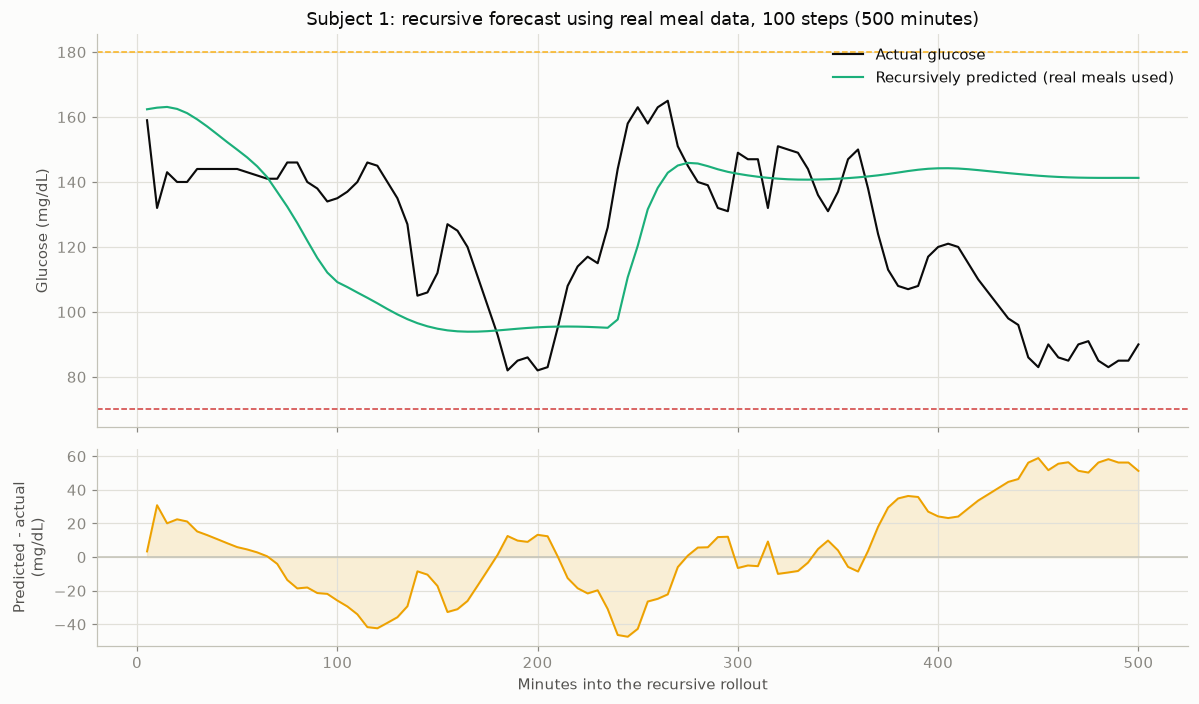

In [11]:
model_oracle = rec.load_multi_output_model(result_oracle)
trajectory_oracle = rec.recursive_forecast(
    model_oracle, enriched, start_idx=start_idx, scaler=data_oracle.scaler,
    target_means=data_oracle.target_means, target_stds=data_oracle.target_stds,
    n_steps=N_STEPS, target_columns=RECURSIVE_TARGETS,
)

minutes_ahead_o = (trajectory_oracle["step"] + 1) * 5
error_o = trajectory_oracle["pred_CGM"] - trajectory_oracle["actual_CGM"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])

ax1.plot(minutes_ahead_o, trajectory_oracle["actual_CGM"], color=plotting.INK_PRIMARY, linewidth=1.4, label="Actual glucose")
ax1.plot(minutes_ahead_o, trajectory_oracle["pred_CGM"], color=plotting.CATEGORICAL[2], linewidth=1.4, label="Recursively predicted (real meals used)")
ax1.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
ax1.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_title(f"Subject {SUBJECT_ID}: recursive forecast using real meal data, {N_STEPS} steps ({N_STEPS*5} minutes)")
ax1.legend(frameon=False)

ax2.axhline(0, color=plotting.BASELINE, linewidth=1)
ax2.plot(minutes_ahead_o, error_o, color=plotting.CATEGORICAL[3], linewidth=1.3)
ax2.fill_between(minutes_ahead_o, error_o, 0, color=plotting.CATEGORICAL[3], alpha=0.15)
ax2.set_ylabel("Predicted - actual\n(mg/dL)")
ax2.set_xlabel("Minutes into the recursive rollout")

fig.tight_layout()
plt.show()

In [12]:
print(f"Mean absolute error, first 30 minutes:   {error_o[minutes_ahead_o <= 30].abs().mean():.1f} mg/dL")
print(f"Mean absolute error, last 30 minutes:     {error_o[minutes_ahead_o >= minutes_ahead_o.max() - 30].abs().mean():.1f} mg/dL")
print(f"Mean absolute error, whole rollout:       {error_o.abs().mean():.1f} mg/dL")
print(f"Max absolute error reached, and at what point:  {error_o.abs().max():.1f} mg/dL at minute {minutes_ahead_o[error_o.abs().idxmax()]}")

Mean absolute error, first 30 minutes:   18.9 mg/dL
Mean absolute error, last 30 minutes:     54.3 mg/dL
Mean absolute error, whole rollout:       23.4 mg/dL
Max absolute error reached, and at what point:  58.9 mg/dL at minute 450


The full-window numbers above mix together two different things: how well the model handles the meal specifically, and how much it drifts over a full 8-hour horizon it was never trained or evaluated at (every model in this project is trained and scored on single steps, not hours-long chains of its own guesses). Isolating error in the roughly 1-hour window right around the real meal (minutes 200-300) separates those two effects -- this is the direct, apples-to-apples test of whether real meal data actually fixes what was diagnosed as broken.

In [13]:
meal_window = (minutes_ahead >= 200) & (minutes_ahead <= 300)
meal_window_o = (minutes_ahead_o >= 200) & (minutes_ahead_o <= 300)

print("Mean absolute error, minutes 200-300 (around the real meal):")
print(f"  Time-of-day, all 4 predicted (incl. meal):  {error[meal_window].abs().mean():.1f} mg/dL")
print(f"  Real meal data, only CGM+basal predicted:   {error_o[meal_window_o].abs().mean():.1f} mg/dL")

Mean absolute error, minutes 200-300 (around the real meal):
  Time-of-day, all 4 predicted (incl. meal):  44.1 mg/dL
  Real meal data, only CGM+basal predicted:   18.5 mg/dL


## 9. Does using the real meal data actually fix it?

Yes, specifically where it was supposed to. **Right around the real meal (minutes 200-300), error drops from 44.1 mg/dL down to 18.5 mg/dL** -- more than half -- and the plot above shows why directly: the predicted curve actually climbs when the meal happens, tracking the real rise to 165 mg/dL, instead of drifting the wrong way like both earlier attempts did. That's the mechanism identified back in section 6 working as intended once the model is not asked to solve an unsolvable problem (guessing when a meal happens) on top of the one it's actually good at (glucose dynamics given what insulin and food are doing).

**The full-window numbers do not show the same clean win, and that's worth being honest about rather than only reporting the number that looks good.** Whole-rollout MAE (23.4 mg/dL) and last-30-minutes MAE (54.3 mg/dL) are both worse than the time-of-day version. Two separate things are going on, neither of which is really about meal prediction:

- **The first few minutes are noisier**, for reasons unrelated to meals -- some run-to-run variance in exactly how the model's own generated trajectory departs from the last real window, visible in the first-30-minute number going up (8.4 to 15.0 to 18.9 mg/dL across the three versions) even though nothing meal-related changed in that window.
- **The back half of the rollout drifts regardless of input quality.** After the meal passes, the predicted curve settles into a new flat plateau around 140 mg/dL and stays there, while the real patient's glucose keeps moving on its own -- a late climb, another dip, a final drop to the high 80s. Nothing in this model's inputs (glucose history, basal, and now real bolus/carbs) explains that later movement, and 500 minutes (over 8 hours) is far beyond the single 5-minute step this model was ever trained or evaluated on. Some of that later gap is likely genuinely unpredictable from these inputs at all, not a fixable modeling gap.

**Where this leaves things:** using real meal data instead of trying to predict it fixes exactly the failure mode diagnosed at the start -- the model can simulate a believable glucose response to a known meal, it just can't know a meal is coming. That's a real, useful result for a shorter horizon (an hour or two around a logged event). It is not a general fix for long, multi-hour recursive forecasting, where accumulated drift over a horizon this far past training shows up regardless of how good the exogenous inputs are.